1. Cargando shapefile desde input/ (Drive)...
[OK] Shapefile detectado: area-estudio.shp

Columnas disponibles en el shapefile:
   1. N_subc               -> ejemplos: 1. Acacias, 2. Caño Chichimene, 3, Caño Colorado
   2. nombre               -> ejemplos: Acacias, Caño Chichimene, Caño Colorado
   3. areakm2              -> ejemplos: 243.566, 227.471, 7.43964

¿Qué columna identifica cada polígono? (nombre o número): 2
   Polígonos detectados (nombre): 13
2. Preparando CHIRPS mensual 2024 (caché: /content/drive/MyDrive/CURSOS/curso agroclima python - rstudio/precipitacion chirps/cache_chirps/chirps_2024)...


CHIRPS:   0%|          | 0/12 [00:00<?, ?mes/s]

3. Recortando y suavizando (bilineal x20)...


Procesando:   0%|          | 0/12 [00:00<?, ?mes/s]

4. Calculando precipitación mensual promedio por subcuenca...


Zonal stats:   0%|          | 0/12 [00:00<?, ?mes/s]

5. Generando gráficos (300 DPI)...


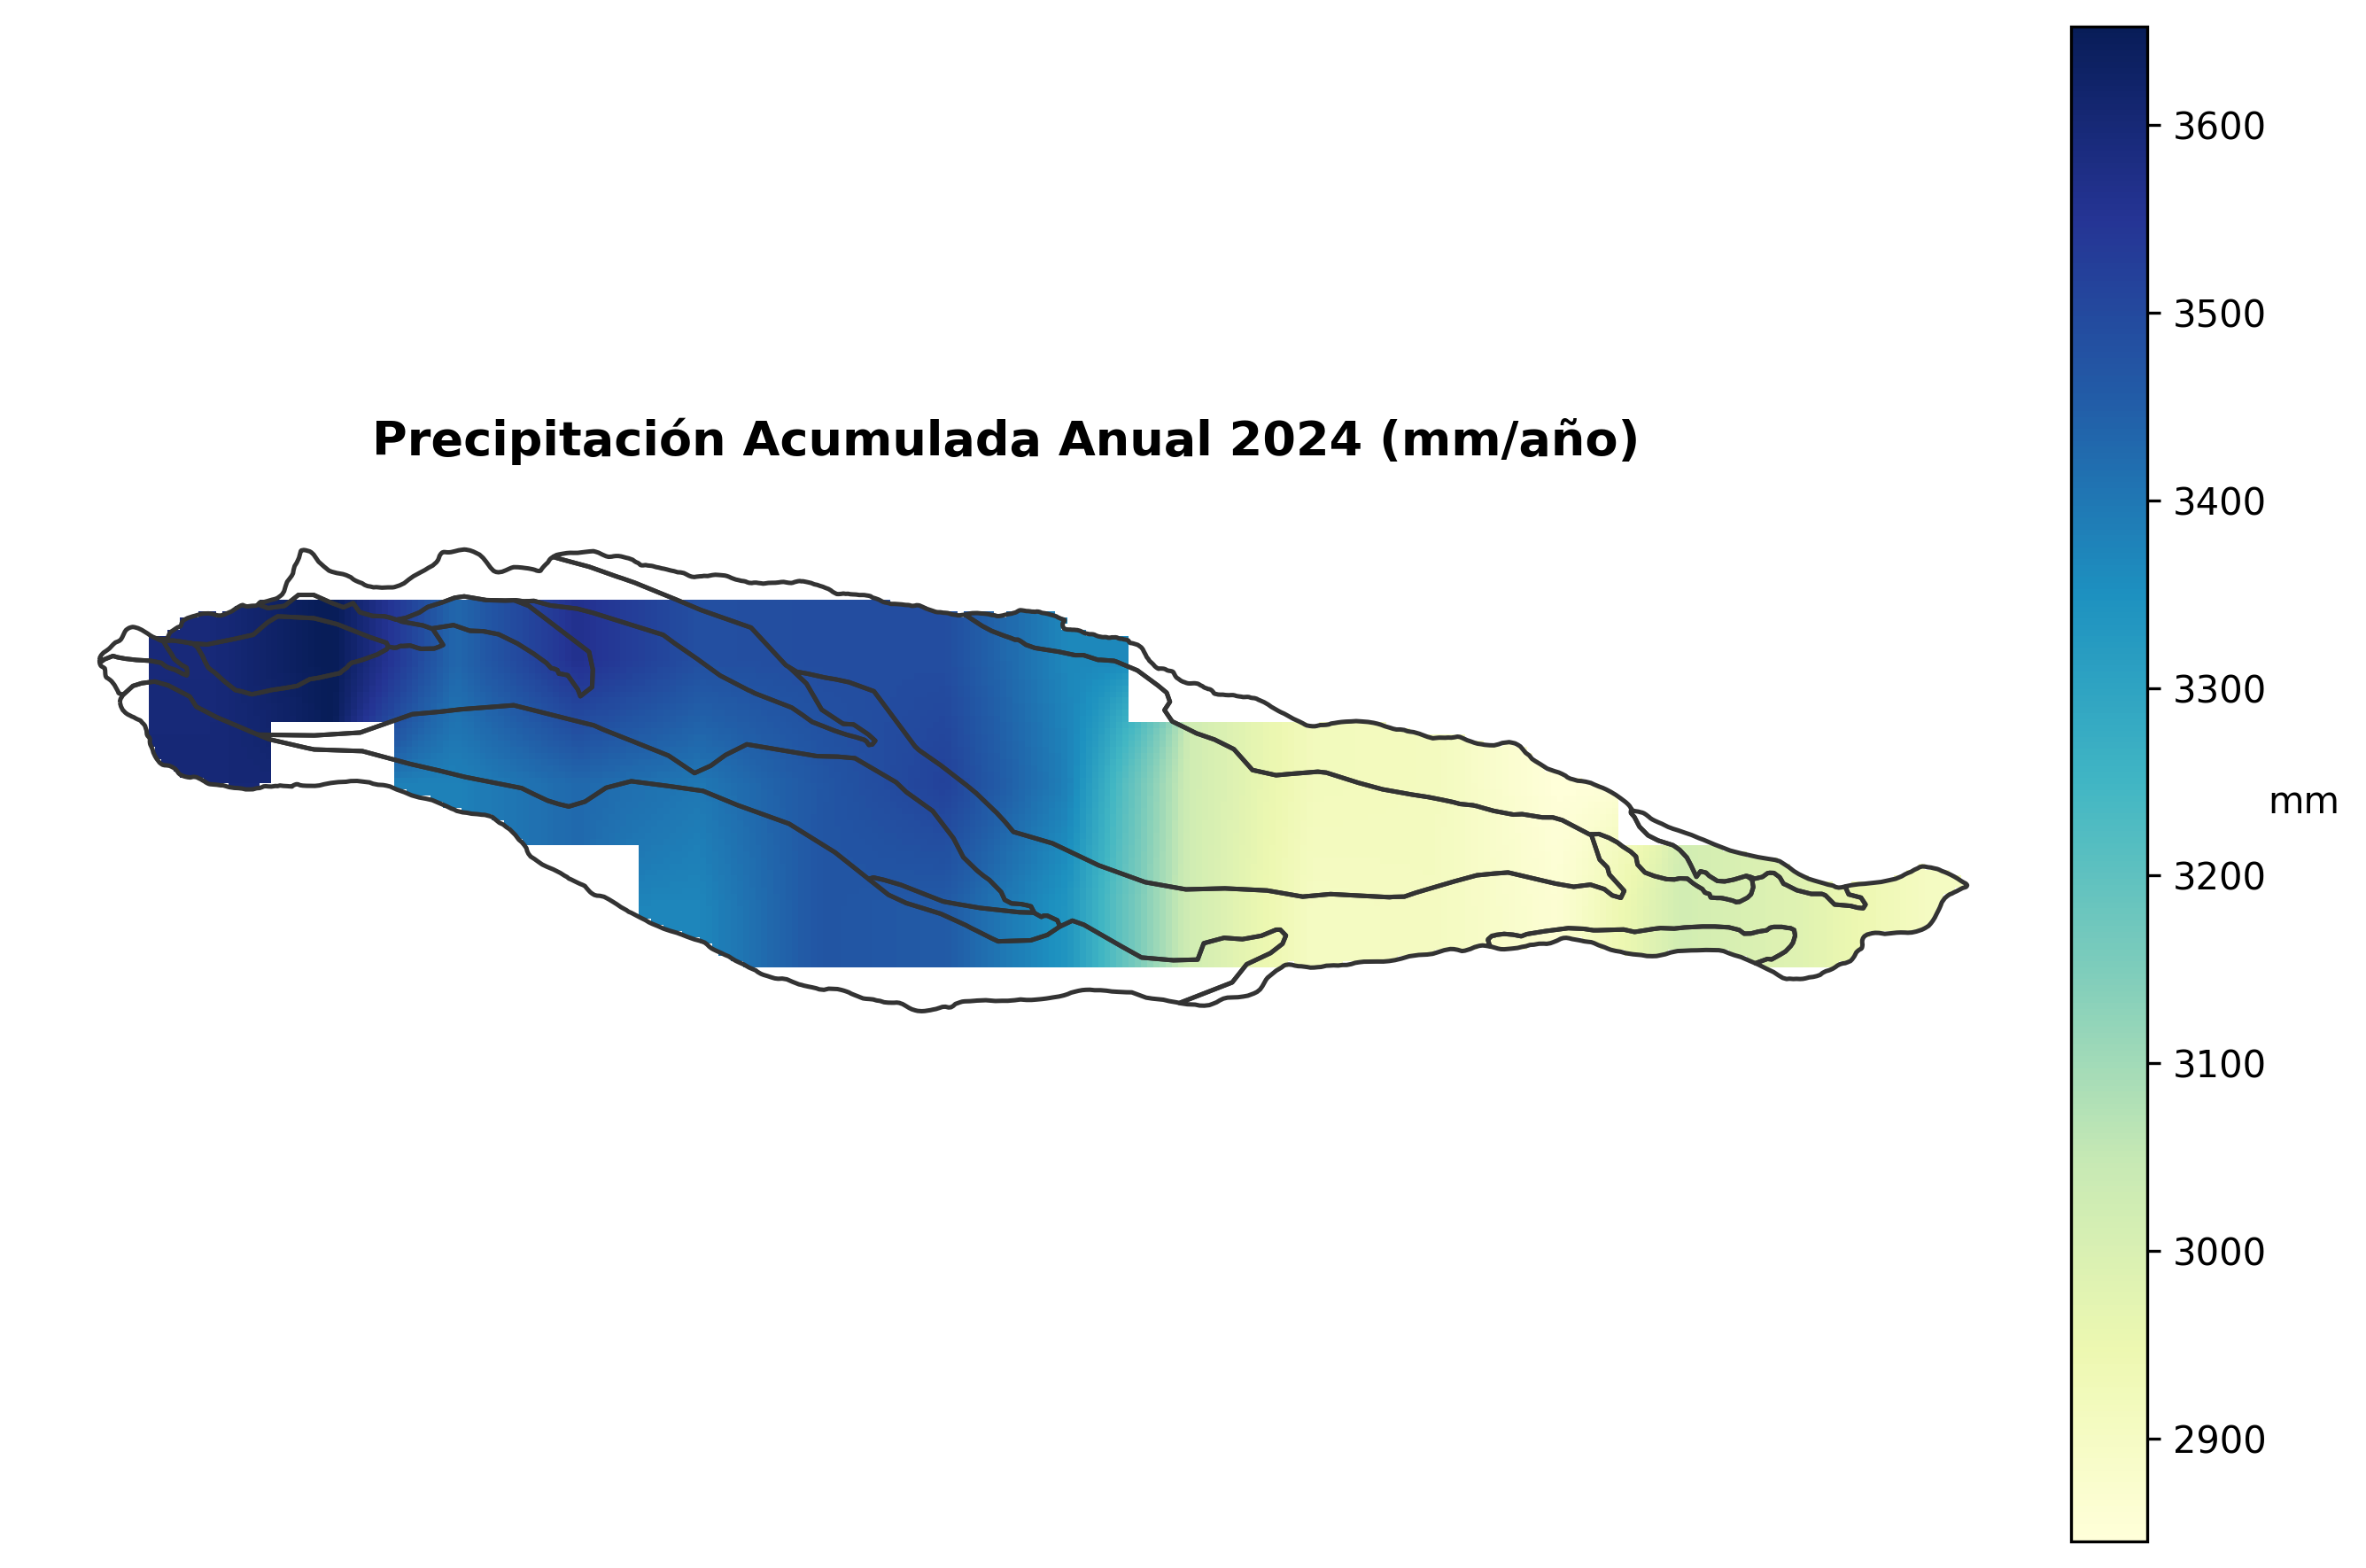

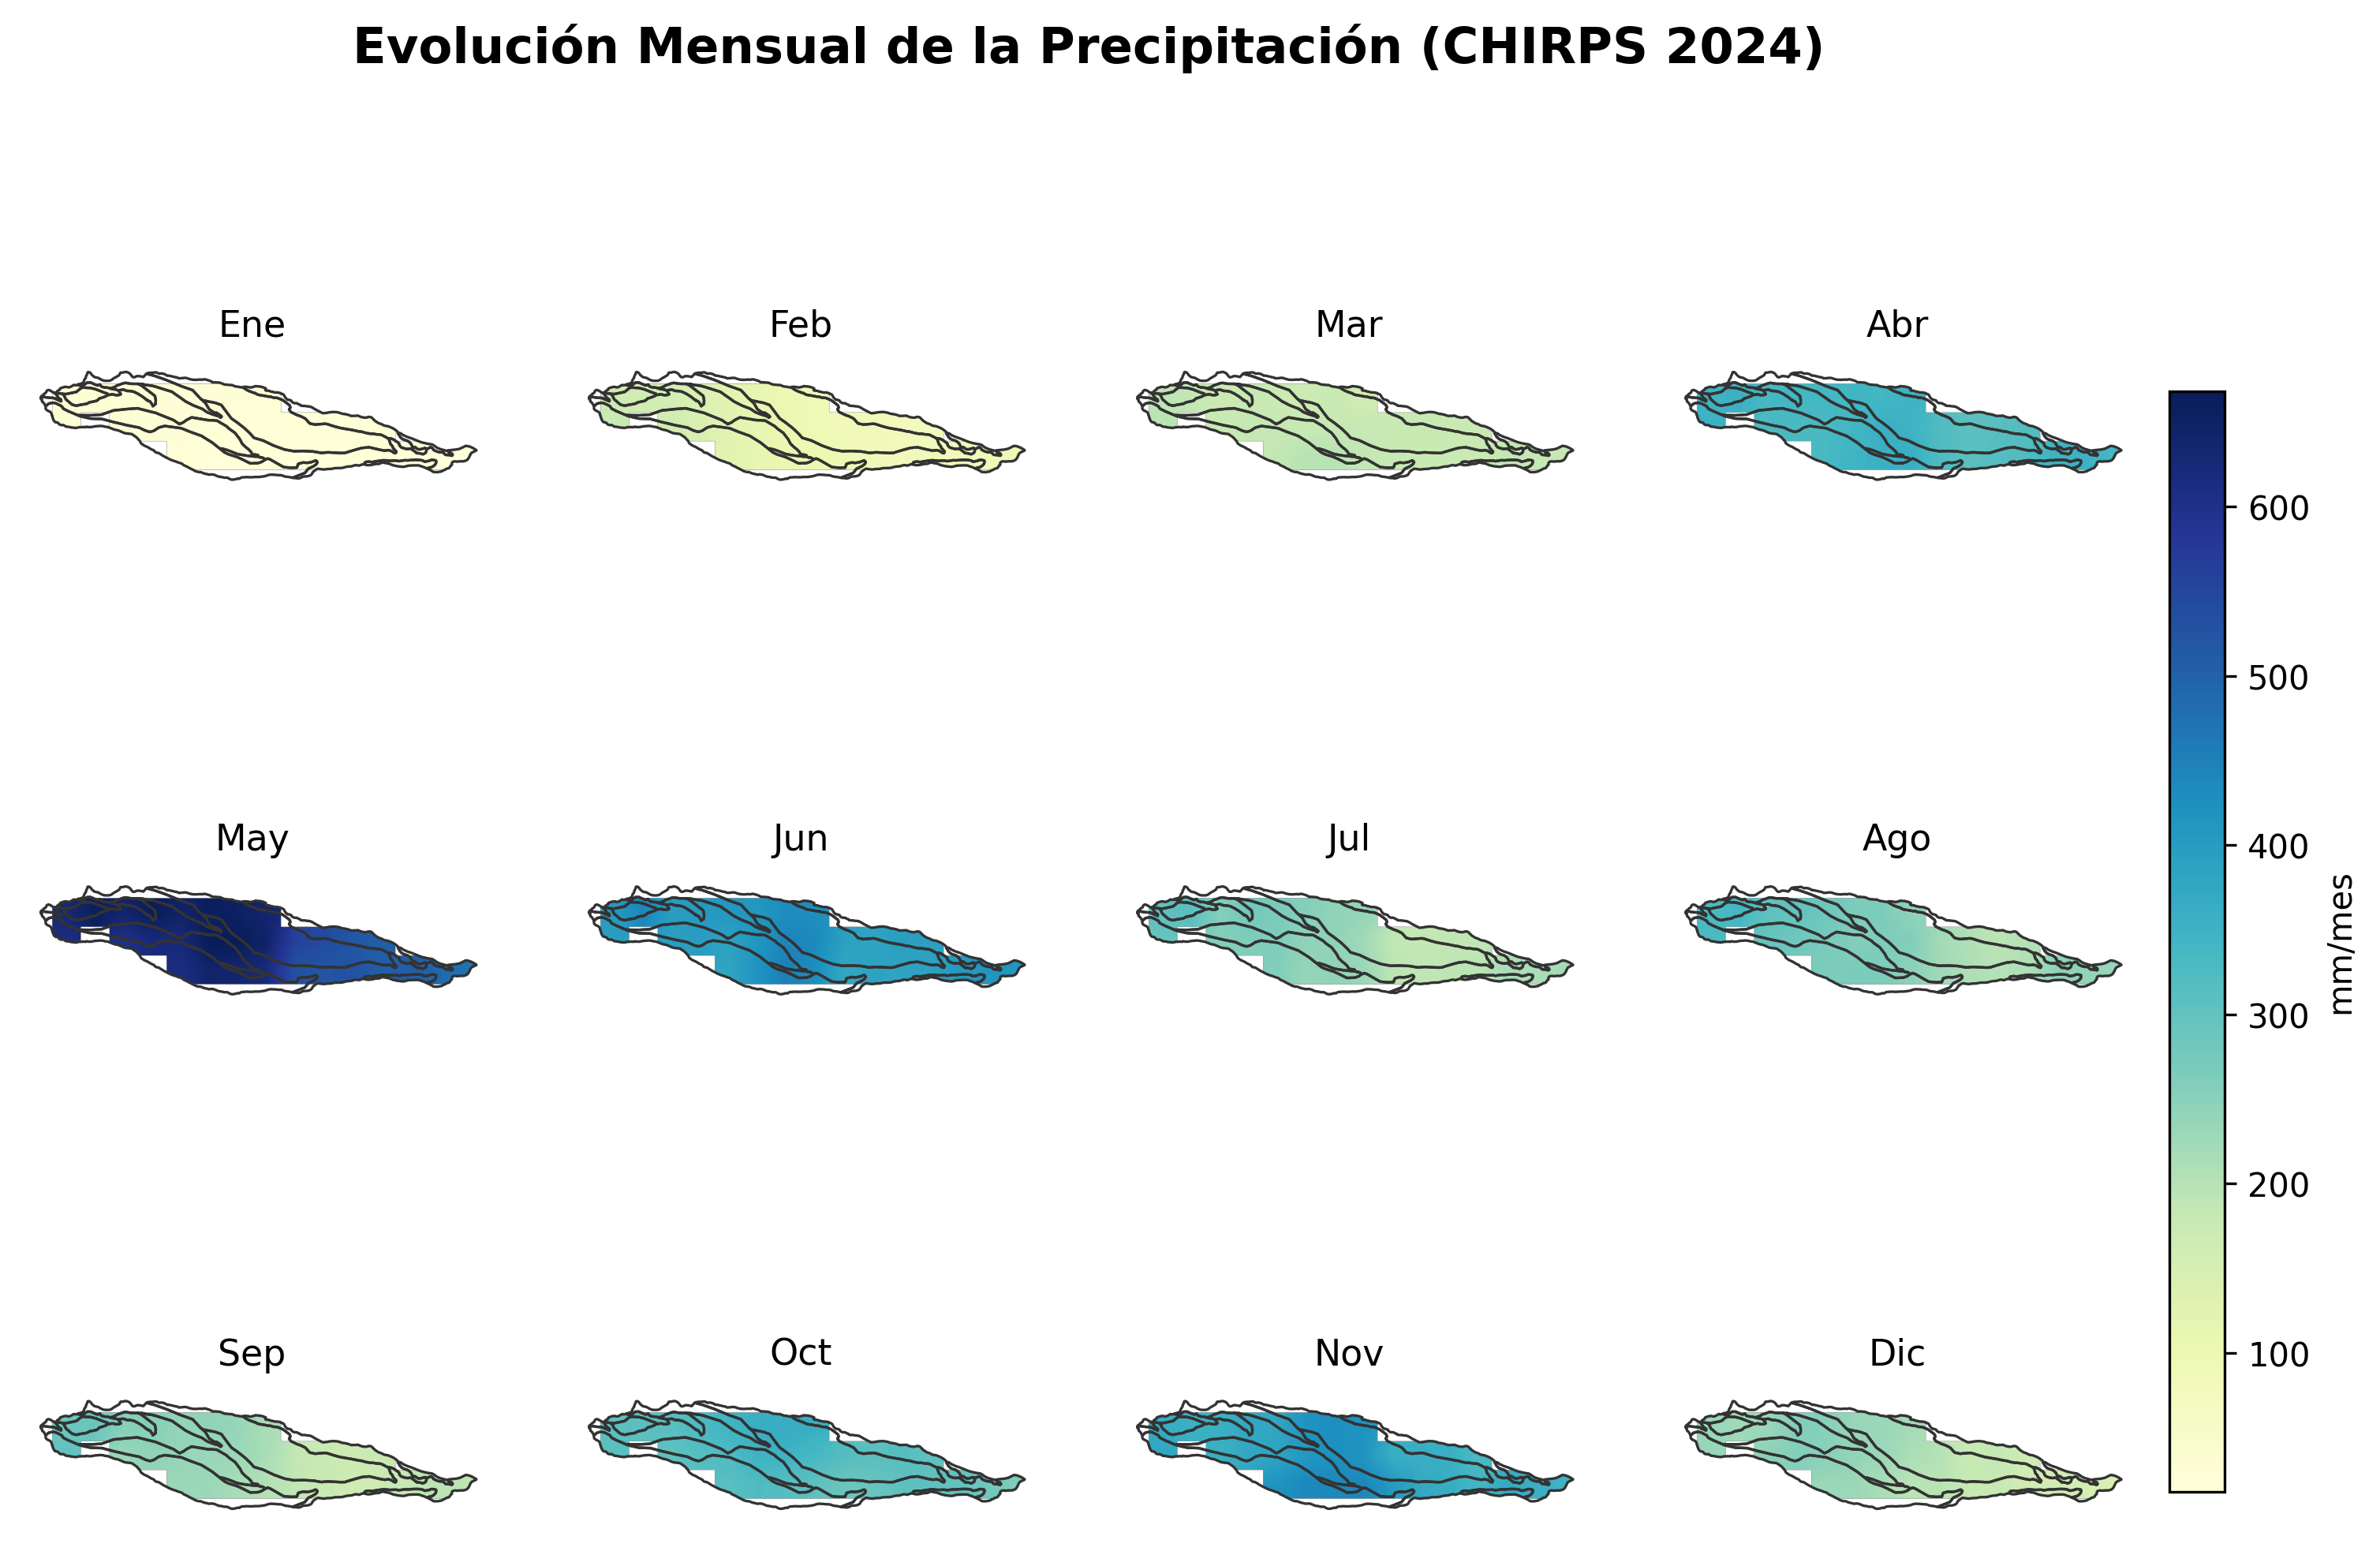

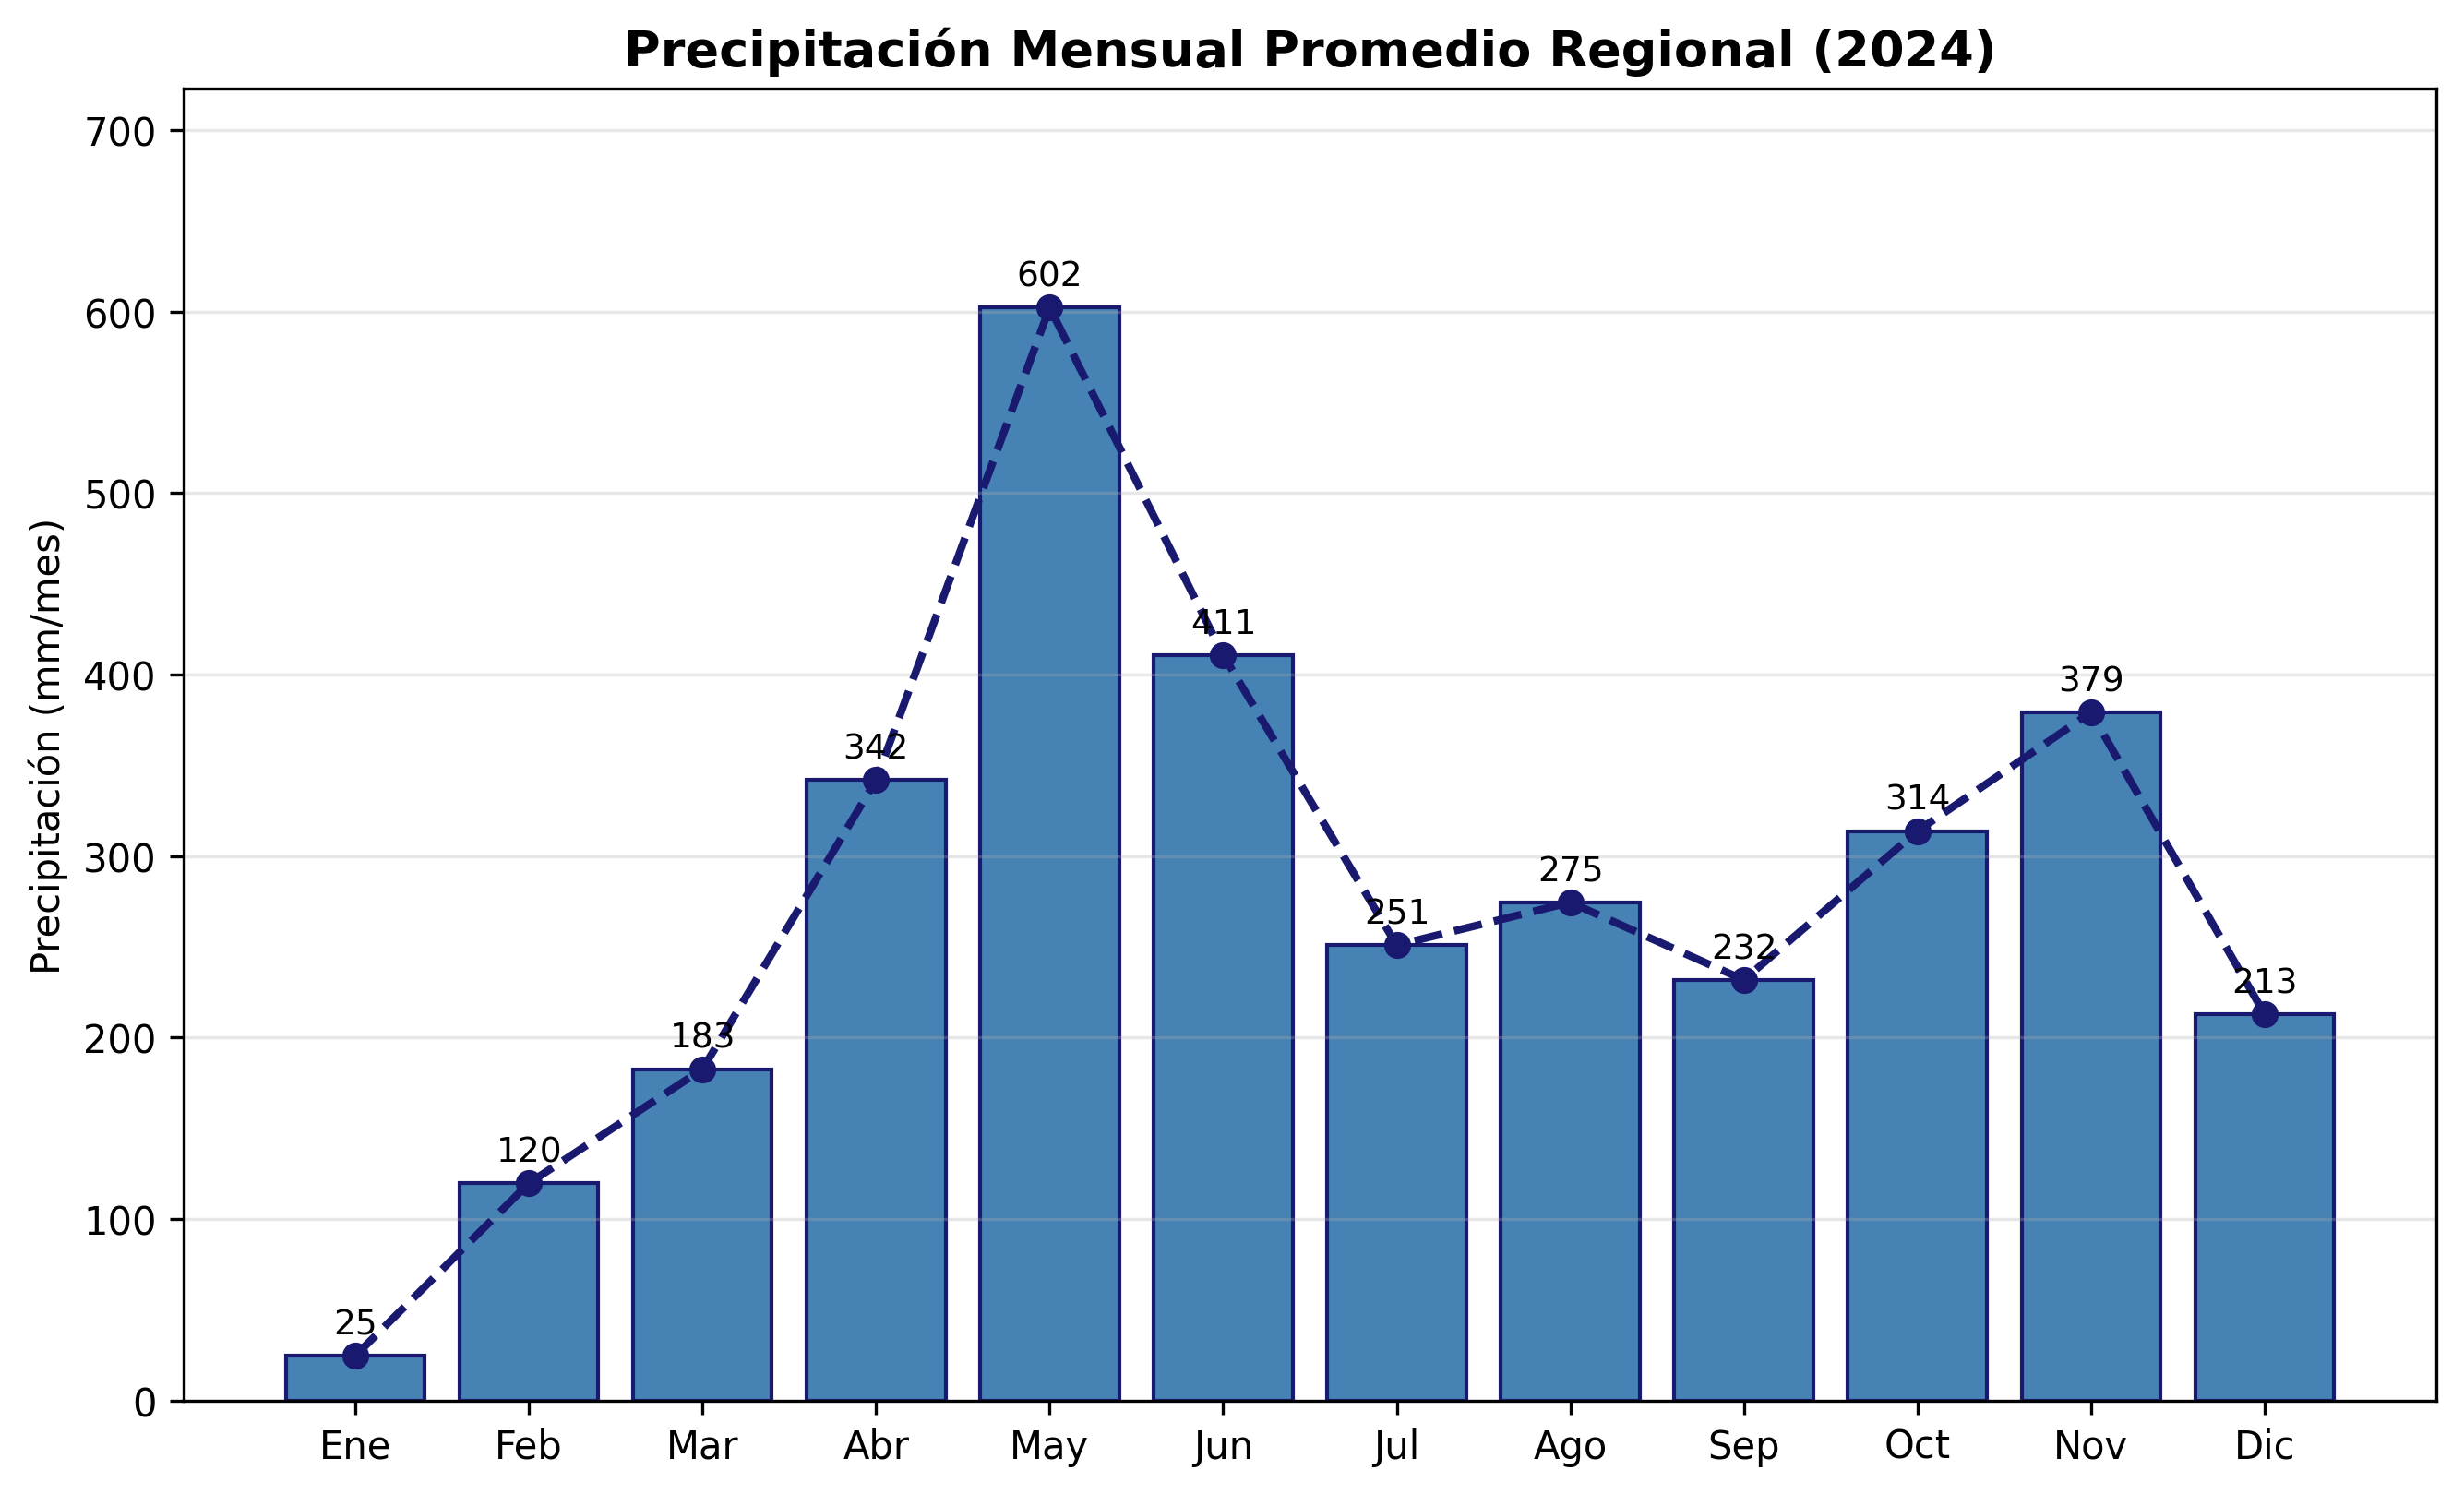

6. Exportando resultados numéricos a Excel...

PROCESO COMPLETADO CON ÉXITO
Carpeta de salida (Drive): /content/drive/MyDrive/CURSOS/curso agroclima python - rstudio/precipitacion chirps/output
  1. Mapa anual:      mapa_anual_precipitacion.png
  2. Mapas 12 meses:  mapas_mensuales_precipitacion.png
  3. Barras:          barras_precipitacion.png
  4. Excel:           resultados_precipitacion_mensual.xlsx


,nombre,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic,Total_Anual_mm
0,Acacias,23.6,110.4,179.2,337.8,588.7,405.7,237.3,259.2,217.9,312.0,380.0,207.6,3259.4
1,Caño Chichimene,22.2,89.2,174.9,331.9,592.3,408.1,215.2,235.9,202.1,328.6,392.2,204.6,3197.2
2,Caño Colorado,20.3,103.4,193.5,355.7,632.7,442.3,239.0,259.0,212.8,313.7,439.2,209.0,3420.6
3,Caño Danta,22.0,79.4,174.6,322.5,538.8,396.7,197.1,213.5,181.7,316.3,361.9,181.2,2985.7
4,Caño Hondo,27.2,127.8,173.9,340.4,652.6,411.2,268.4,286.7,246.8,340.4,383.9,244.9,3504.2
5,Caño La Union,24.3,126.4,182.7,339.5,639.1,411.7,253.2,274.8,235.2,325.9,395.4,240.1,3448.3
6,Caño Palmaquemada,29.3,147.3,176.4,338.6,652.0,401.4,269.8,301.4,255.8,319.2,365.1,245.8,3502.1
7,Caño Pinitas,20.4,80.0,180.5,340.4,503.9,401.1,207.9,231.4,181.6,297.4,358.2,158.6,2961.4
8,Caño Santa Bàrbara,19.9,81.6,183.1,350.1,495.0,410.4,213.9,242.3,190.1,287.9,361.4,154.7,2990.4
9,Drenaje S/N,30.3,165.9,193.1,348.4,625.4,403.2,304.1,329.8,286.9,306.1,366.6,234.8,3594.6


In [1]:
# ==============================================================================
# ANÁLISIS AGROCLIMÁTICO: PRECIPITACIÓN (CHIRPS v2.0) — VERSIÓN GOOGLE COLAB
# ==============================================================================
# Autor: Oscar Vargas Pineda — Trabajo Científico (@TCientifico)
# Curso: Agroclima Python + RStudio
#
# Fuente: Climate Hazards Group InfraRed Precipitation with Station data
#         UCSB Climate Hazards Center  —  Resolución 0.05° (~5 km), mensual (mm)
#
# Genera en la carpeta output/ del proyecto en Drive:
#   - mapa_anual_precipitacion.png
#   - mapas_mensuales_precipitacion.png
#   - barras_precipitacion.png
#   - resultados_precipitacion_mensual.xlsx
# ==============================================================================

# ------------------------------------------------------------------------------
# CELDA 0 — (Ejecutar UNA sola vez por sesión, antes de correr este script)
# ------------------------------------------------------------------------------
# from google.colab import drive
# drive.mount('/content/drive')
# ------------------------------------------------------------------------------

# ==============================================================================
# CELDA 1 — INSTALACIÓN DE DEPENDENCIAS (Colab no trae rasterstats por defecto)
# ==============================================================================
# Descomenta estas líneas la primera vez que ejecutes en una sesión nueva.
# Luego puedes volver a comentarlas para agilizar reejecuciones.
#
# !pip install -q rasterstats tqdm openpyxl
# !pip install -q --upgrade geopandas rasterio

# ==============================================================================
# CELDA 2 — SCRIPT PRINCIPAL
# ==============================================================================
import glob
import gzip
import os
import shutil
import urllib.request
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import Normalize
from rasterio.features import geometry_mask
from rasterio.mask import mask as rio_mask
from rasterio.transform import Affine
from rasterio.warp import Resampling, reproject
from rasterstats import zonal_stats
from tqdm.auto import tqdm

# ------------------------------------------------------------------------------
# PARÁMETROS EDITABLES POR EL USUARIO
# ------------------------------------------------------------------------------
# Ruta raíz del proyecto en Google Drive (contiene input/ y output/)
PROYECTO_DIR = Path(
    "/content/drive/MyDrive/CURSOS/curso agroclima python - rstudio/precipitacion chirps"
)

# Año de análisis (cambiar libremente: 2022, 2023, 2024, ...)
ANIO = 2024

# Factor de suavizado (equivale a disagg fact=20 en R). Genera píxeles ~20×
# más finos para que subcuencas pequeñas contengan suficientes celdas.
# OJO: valores altos consumen mucha RAM. Si tu área es grande, prueba 10 o 5.
FACTOR_UPSAMPLE = 20

# Si True, los GeoTIFFs descomprimidos se cachean en Drive para no volver a
# descargarlos al reiniciar el runtime de Colab.
USAR_CACHE_DRIVE = True
# ------------------------------------------------------------------------------

URL_BASE = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_monthly/tifs"
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
NODATA_CHIRPS = -9999.0

# Estructura de carpetas del proyecto
DIR_INPUT = PROYECTO_DIR / "input"
DIR_OUTPUT = PROYECTO_DIR / "output"
DIR_CACHE = PROYECTO_DIR / "cache_chirps"
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)
if USAR_CACHE_DRIVE:
    DIR_CACHE.mkdir(parents=True, exist_ok=True)

# Verificación previa: ¿Drive está montado?
if not PROYECTO_DIR.exists():
    raise SystemExit(
        f"[ERROR] No se encuentra la carpeta del proyecto:\n  {PROYECTO_DIR}\n"
        "Ejecuta primero la CELDA 0 para montar Google Drive."
    )


# ==============================================================================
# UTILIDADES
# ==============================================================================
def encontrar_shapefile():
    """Detecta un .shp en input/ (cualquier nombre, hasta 1 nivel de subcarpetas)."""
    if not DIR_INPUT.is_dir():
        raise SystemExit(
            f"[ERROR] No existe {DIR_INPUT}/. Créala y coloca ahí tu shapefile."
        )
    encontrados = sorted(
        set(list(DIR_INPUT.glob("*.shp")) + list(DIR_INPUT.glob("*/*.shp")))
    )
    if not encontrados:
        raise SystemExit(f"[ERROR] No se encontró ningún .shp dentro de {DIR_INPUT}/")
    if len(encontrados) == 1:
        print(f"[OK] Shapefile detectado: {encontrados[0].name}")
        return encontrados[0]
    print("Se encontraron varios shapefiles en input/. Elige uno:")
    for i, ruta in enumerate(encontrados, 1):
        print(f"  {i}. {ruta.name}")
    while True:
        resp = input("Número del shapefile: ").strip()
        if resp.isdigit() and 1 <= int(resp) <= len(encontrados):
            return encontrados[int(resp) - 1]
        print("Entrada inválida.")


def elegir_columna(gdf):
    """Lista columnas del shapefile y pide al usuario cuál es el ID del polígono."""
    cols = [c for c in gdf.columns if c.lower() != "geometry"]
    print("\nColumnas disponibles en el shapefile:")
    for i, c in enumerate(cols, 1):
        muestra = ", ".join(gdf[c].dropna().astype(str).head(3).tolist()) or "(sin datos)"
        print(f"  {i:2d}. {c:20s} -> ejemplos: {muestra}")
    while True:
        resp = input("\n¿Qué columna identifica cada polígono? (nombre o número): ").strip()
        if not resp:
            continue
        if resp.isdigit() and 1 <= int(resp) <= len(cols):
            return cols[int(resp) - 1]
        if resp in cols:
            return resp
        print("Entrada inválida.")


def descargar_chirps_mes(mes, dir_destino):
    """Descarga y descomprime un GeoTIFF mensual de CHIRPS. Usa caché si existe."""
    nombre = f"chirps-v2.0.{ANIO}.{mes:02d}.tif"
    tif_path = dir_destino / nombre
    if tif_path.exists() and tif_path.stat().st_size > 0:
        return tif_path  # ya estaba cacheado
    gz_path = dir_destino / (nombre + ".gz")
    url = f"{URL_BASE}/{nombre}.gz"
    urllib.request.urlretrieve(url, gz_path)
    with gzip.open(gz_path, "rb") as fin, open(tif_path, "wb") as fout:
        shutil.copyfileobj(fin, fout)
    gz_path.unlink(missing_ok=True)
    return tif_path


def upsample_bilinear(src_array, src_transform, factor):
    """Remuestrea un array 2D por `factor` con interpolación bilineal."""
    h, w = src_array.shape
    new_h, new_w = h * factor, w * factor
    new_transform = Affine(
        src_transform.a / factor, src_transform.b, src_transform.c,
        src_transform.d, src_transform.e / factor, src_transform.f,
    )
    dest = np.full((new_h, new_w), np.nan, dtype="float32")
    reproject(
        source=np.ascontiguousarray(src_array),
        destination=dest,
        src_transform=src_transform,
        src_crs="EPSG:4326",
        dst_transform=new_transform,
        dst_crs="EPSG:4326",
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear,
    )
    return dest, new_transform


# ==============================================================================
# 1. CARGAR SHAPEFILE
# ==============================================================================
print("1. Cargando shapefile desde input/ (Drive)...")
ruta_shp = encontrar_shapefile()
poligono = gpd.read_file(ruta_shp).to_crs("EPSG:4326")
col_id = elegir_columna(poligono)
nombres_subc = poligono[col_id].astype(str).tolist()
geoms = list(poligono.geometry.values)
print(f"   Polígonos detectados ({col_id}): {len(nombres_subc)}")

# Rutas de salida (todas bajo output/ en Drive)
OUT_EXCEL = DIR_OUTPUT / "resultados_precipitacion_mensual.xlsx"
OUT_MAPA_ANUAL = DIR_OUTPUT / "mapa_anual_precipitacion.png"
OUT_MAPAS_MENSUALES = DIR_OUTPUT / "mapas_mensuales_precipitacion.png"
OUT_BARRAS = DIR_OUTPUT / "barras_precipitacion.png"

# ==============================================================================
# 2. DESCARGAR 12 GEOTIFFs DE CHIRPS (con barra de progreso y caché opcional)
# ==============================================================================
if USAR_CACHE_DRIVE:
    dir_tifs = DIR_CACHE / f"chirps_{ANIO}"
    dir_tifs.mkdir(parents=True, exist_ok=True)
    print(f"2. Preparando CHIRPS mensual {ANIO} (caché: {dir_tifs})...")
else:
    dir_tifs = Path("/content") / f"chirps_tmp_{ANIO}"
    dir_tifs.mkdir(parents=True, exist_ok=True)
    print(f"2. Descargando CHIRPS mensual {ANIO} (temporal, sin caché)...")

tif_mensuales = []
for m in tqdm(range(1, 13), desc="CHIRPS", unit="mes"):
    tif_mensuales.append(descargar_chirps_mes(m, dir_tifs))

# ==============================================================================
# 3. RECORTAR + REMUESTREAR BILINEAL + ENMASCARAR
# ==============================================================================
print(f"3. Recortando y suavizando (bilineal x{FACTOR_UPSAMPLE})...")

stack = []
transform_ref = None
mascara_fuera = None
for tif in tqdm(tif_mensuales, desc="Procesando", unit="mes"):
    with rasterio.open(tif) as src:
        arr, tr = rio_mask(src, geoms, crop=True, nodata=np.nan, filled=True)
    banda = arr[0].astype("float32")
    banda[banda <= NODATA_CHIRPS + 1] = np.nan

    banda_hd, tr_hd = upsample_bilinear(banda, tr, FACTOR_UPSAMPLE)

    if mascara_fuera is None:
        mascara_fuera = geometry_mask(
            geoms,
            transform=tr_hd,
            out_shape=banda_hd.shape,
            invert=False,
        )
    banda_hd[mascara_fuera] = np.nan
    stack.append(banda_hd)
    transform_ref = tr_hd

stack = np.stack(stack, axis=0)

h, w = stack.shape[1], stack.shape[2]
x_min = transform_ref.c
y_max = transform_ref.f
x_max = x_min + w * transform_ref.a
y_min = y_max + h * transform_ref.e
extent = (x_min, x_max, y_min, y_max)

anual = np.nansum(stack, axis=0)
anual[np.all(np.isnan(stack), axis=0)] = np.nan

# ==============================================================================
# 4. ZONAL STATS SOBRE EL RÁSTER REMUESTREADO
# ==============================================================================
print("4. Calculando precipitación mensual promedio por subcuenca...")
filas = []
for banda_hd in tqdm(stack, desc="Zonal stats", unit="mes"):
    banda_calc = np.where(np.isnan(banda_hd), -9999.0, banda_hd).astype("float32")
    stats = zonal_stats(
        poligono, banda_calc,
        affine=transform_ref,
        stats="mean",
        all_touched=True,
        nodata=-9999.0,
    )
    filas.append([s["mean"] if s["mean"] is not None else np.nan for s in stats])

matriz = np.array(filas).T
tabla = pd.DataFrame(matriz, columns=MESES)
tabla.insert(0, col_id, nombres_subc)
tabla[MESES] = tabla[MESES].round(1)
tabla["Total_Anual_mm"] = tabla[MESES].sum(axis=1).round(1)

# ==============================================================================
# 5. GRÁFICOS (guardados en Drive + mostrados inline)
# ==============================================================================
print("5. Generando gráficos (300 DPI)...")
cmap_lluvia = "YlGnBu"


def dibujar_mapa_anual():
    fig, ax = plt.subplots(figsize=(9, 6), dpi=300)
    im = ax.imshow(anual, cmap=cmap_lluvia, extent=extent, origin="upper")
    poligono.boundary.plot(ax=ax, color="#333333", linewidth=1.2)
    ax.set_title(f"Precipitación Acumulada Anual {ANIO} (mm/año)",
                 fontsize=13, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    for side in ax.spines.values():
        side.set_visible(False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("mm", rotation=0, labelpad=10)
    fig.tight_layout()
    fig.savefig(OUT_MAPA_ANUAL, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def dibujar_mapas_mensuales():
    vmin = np.nanmin(stack); vmax = np.nanmax(stack)
    norm = Normalize(vmin=vmin, vmax=vmax)
    fig, axes = plt.subplots(3, 4, figsize=(12, 8), dpi=300)
    for i, ax in enumerate(axes.flat):
        ax.imshow(stack[i], cmap=cmap_lluvia, norm=norm,
                  extent=extent, origin="upper")
        poligono.boundary.plot(ax=ax, color="#333333", linewidth=0.8)
        ax.set_title(MESES[i], fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        for side in ax.spines.values():
            side.set_visible(False)
    fig.suptitle(f"Evolución Mensual de la Precipitación (CHIRPS {ANIO})",
                 fontsize=15, fontweight="bold", y=0.98)
    sm = plt.cm.ScalarMappable(cmap=cmap_lluvia, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(),
                        fraction=0.025, pad=0.02)
    cbar.set_label("mm/mes")
    fig.savefig(OUT_MAPAS_MENSUALES, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def dibujar_barras():
    promedio_regional = tabla[MESES].mean(axis=0).values
    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)
    barras = ax.bar(MESES, promedio_regional,
                    color="steelblue", edgecolor="midnightblue")
    ax.plot(MESES, promedio_regional, color="midnightblue",
            linewidth=2, linestyle="--", marker="o")
    for rect, valor in zip(barras, promedio_regional):
        ax.text(rect.get_x() + rect.get_width() / 2,
                rect.get_height() + max(promedio_regional) * 0.02,
                f"{valor:.0f}", ha="center", fontsize=9)
    ax.set_title(f"Precipitación Mensual Promedio Regional ({ANIO})",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Precipitación (mm/mes)")
    ax.set_ylim(0, max(promedio_regional) * 1.2)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_BARRAS, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


dibujar_mapa_anual()
dibujar_mapas_mensuales()
dibujar_barras()

# ==============================================================================
# 6. EXPORTAR EXCEL
# ==============================================================================
print("6. Exportando resultados numéricos a Excel...")
tabla.to_excel(OUT_EXCEL, index=False)

# Limpieza del directorio temporal si no se usó caché
if not USAR_CACHE_DRIVE:
    shutil.rmtree(dir_tifs, ignore_errors=True)

print("\n====================================================")
print("PROCESO COMPLETADO CON ÉXITO")
print(f"Carpeta de salida (Drive): {DIR_OUTPUT}")
print(f"  1. Mapa anual:      {OUT_MAPA_ANUAL.name}")
print(f"  2. Mapas 12 meses:  {OUT_MAPAS_MENSUALES.name}")
print(f"  3. Barras:          {OUT_BARRAS.name}")
print(f"  4. Excel:           {OUT_EXCEL.name}")
print("====================================================")

# Vista previa de la tabla numérica
tabla